In [6]:
import copy
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

import torchvision
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from sm import NeuralNet, LearnableActivationFunc
from sm import LearnableActivationFunc
from models import CondSM

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [7]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

train_ds = datasets.MNIST(root='./data', train=True, download=False, transform=transform)
test_ds  = datasets.MNIST(root='./data', train=False, download=False, transform=transform)

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True, num_workers=2)
test_loader  = DataLoader(test_ds, batch_size=256, shuffle=False, num_workers=2)
len(train_ds), len(test_ds)

(60000, 10000)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.42421296..2.8214867].


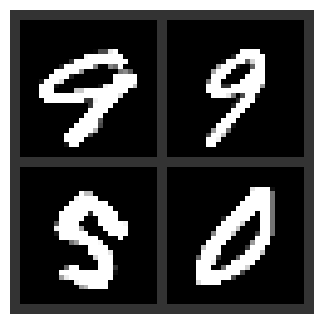

In [8]:
import torch
import matplotlib.pyplot as plt
from torchvision.utils import make_grid

batch = next(iter(train_loader))
imgs, labels = batch

grid = make_grid(imgs[:4], nrow=2, padding=2, pad_value=0.2)  # (C, H, W)
fig, ax = plt.subplots(figsize=(4, 4))

ax.set_position([0.18, 0.12, 0.76, 0.83])

ax.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
ax.axis("off")

plt.savefig('mnist_data.pdf')
plt.show()

In [9]:
data_type = 'grad_towards_1e7'
state_dict = torch.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data/final_datasets/{data_type}/sm_{data_type}_baseline_0_epochs=1000_dp=0.1_bn=True_hd=90_ls=5_noise=True.pth', weights_only=False, map_location='cuda')

model = CondSM(state_dict['layer_dims'], state_dict['dropout'], state_dict['batch_norm'])
model.load_state_dict(state_dict['model_state_dict'])

class SmallCNN(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)   # 28x28 -> 28x28
        self.pool  = nn.MaxPool2d(2, 2)                # 28x28 -> 14x14
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)   # 14x14 -> 14x14
        self.fc1   = nn.Linear(32 * 14 * 14, 64)
        self.fc2   = nn.Linear(64, 10)

        self.act1 = LearnableActivationFunc(model, 0, -1.5, 1.5, None, device=None)
        self.act2 = LearnableActivationFunc(model, 0, -1.5, 1.5, None, device=None)
        self.act3 = LearnableActivationFunc(model, 0, -1.5, 1.5, None, device=None)

    def forward(self, x):
        x = self.conv1(x)
        x = self.act1(x)
        x = self.conv2(x)
        x = self.act2(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = self.act3(x)
        x = self.fc2(x)
        return x

net = SmallCNN(model).to(device)
sum(p.numel() for p in net.parameters())

460133

In [10]:
optimizer = torch.optim.Adam(net.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
EPOCHS = 10
training_loss = []
test_accuracies = []
for epoch in range(1, EPOCHS+1):
    net.train()
    running_loss, correct, total = 0.0, 0, 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)
        out = net(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x.size(0)
        pred = out.argmax(1)
        correct += (pred == y).sum().item()
        total += y.size(0)

    train_loss = running_loss / total
    train_acc = correct / total
    print(f'Training | Epoch {epoch}/{EPOCHS} | Loss: {train_loss:.4f} | Acc: {100. * train_acc:.4f}')
    
    net.eval()
    with torch.no_grad():
        running_loss = 0.0
        correct = 0
        total = 0
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            out = net(x)

            loss = criterion(out, y)
            running_loss += loss.item() * x.size(0)
            pred = out.argmax(1)
            correct += (pred == y).sum().item()
            total += y.size(0)
        print(f'Testing | Loss: {running_loss / total} | Acc: {100. * correct / total:.4f}')
        test_accuracies.append(100. * correct / total)
        training_loss.append(train_loss)

torch.save({
        "model_state_dict": net.state_dict(),
        "test_accuracy": test_accuracies,
        "training_loss": training_loss
    }, f'/gpfs/bwfor/work/ws/hd_gy283-my_data/models/data_type={data_type}_mnist.pth')

Training | Epoch 1/10 | Loss: 0.9747 | Acc: 87.6583
Testing | Loss: 0.23125236132144927 | Acc: 96.7100
Training | Epoch 2/10 | Loss: 0.1352 | Acc: 97.6067
Testing | Loss: 0.08126105902791023 | Acc: 98.2200
Training | Epoch 3/10 | Loss: 0.0687 | Acc: 98.5000
Testing | Loss: 0.05992124045044184 | Acc: 98.5700
Training | Epoch 4/10 | Loss: 0.0464 | Acc: 98.9300
Testing | Loss: 0.04780980987995863 | Acc: 98.6400
Training | Epoch 5/10 | Loss: 0.0338 | Acc: 99.2183
Testing | Loss: 0.04392854844108224 | Acc: 98.7100
Training | Epoch 6/10 | Loss: 0.0256 | Acc: 99.4217
Testing | Loss: 0.04184463787302375 | Acc: 98.7100
Training | Epoch 7/10 | Loss: 0.0194 | Acc: 99.5833
Testing | Loss: 0.038049207275733354 | Acc: 98.7600
Training | Epoch 8/10 | Loss: 0.0143 | Acc: 99.7450
Testing | Loss: 0.035487355379201474 | Acc: 98.9100
Training | Epoch 9/10 | Loss: 0.0104 | Acc: 99.8233
Testing | Loss: 0.03461667129453272 | Acc: 98.8800
Training | Epoch 10/10 | Loss: 0.0087 | Acc: 99.8733
Testing | Loss: 0.